# Identification of *de-novo* promoters

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from tqdm.notebook import tqdm

import copy


import matplotlib.pyplot as plt

import regseq2

regseq2.viz.matplotlib_style()

server = False

In [2]:
def get_pixels(points, matplotlib_dpi=100):
    illustrator_dpi = 72
    
    return points/illustrator_dpi * matplotlib_dpi 

In [3]:
def calculate_confidence_interval(data, confidence=0.95):
  """
  Calculates the confidence interval for a given dataset.

  Args:
    data: A list or numpy array of data values.
    confidence: The desired confidence level (e.g., 0.95 for 95% confidence).

  Returns:
    A tuple containing the lower and upper bounds of the confidence interval.
  """
  data = np.array(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  interval = std_err * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
  return (mean - interval, mean + interval)

In [4]:
def one_hot_encode(seq):
    mapping = dict(zip("ACGT", range(4)))    
    seq2 = [mapping[i] for i in seq]
    return np.eye(4)[seq2]

In [5]:
growth_conditions = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=';')

In [43]:
df_triage = pd.read_csv("triaging.csv")
#df_triage = df_triage[df_triage.classification == 1]
df_triage.head()

,promoter,gc,rep,cv,cv_smooth,entropy,entropy_smooth,classification
0,araBp,29,2,5.105271,1.938526,4.787686,6.292157,1
1,mglBp,9,2,4.801802,1.775373,4.960044,6.371064,1
2,araBp,41,2,4.614532,1.676568,5.100020,6.498608,1
3,araBp,9,2,4.604240,1.720245,5.004471,6.446054,1
4,araBp,13,2,4.586132,1.671479,5.070243,6.494205,1


## Import sequences

In [44]:
df_seqs = pd.read_csv("../../data/metadata/twist_order_sequences.csv")
df_seqs.head()

,genes,sequence,promoter,fwd_primer,rev_primer1,rev_primer2,rev_primer3,upstream_re_site,downstream_re_site,name
0,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTTTTCATCTTTTGTCAACCAT...,rspAp,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_0
1,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTTCTGATCTTTTGTAAATCAT...,rspAp,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_1
2,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTTTTCATCTTTTCTCAACCAC...,rspAp,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_2
3,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTGTTCATCCTTCTTCAACCAT...,rspAp,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_3
4,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTTTTCATCTTTTGTCAACCAT...,rspAp,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_4


## Get dominant mutation

In [45]:
dict_int_to_base = {
    '1': 'A',
    '2': 'C',
    '3': 'G',
    '4': 'T'
}

dict_base_to_int = {
    'A': 1,
    'C': 2,
    'G': 3,
    'T': 4
}


def get_seqs(prom, gc, rep):
    # import expression shift
    df = pd.read_csv(f"../../data/expression_shifts/{gc}-{rep}_exshifts.csv")
    df = df[df['promoter'] == prom]
    # find mutation with highest expression shift
    ind = np.argmax(df['expression_shift'].values)
    pos = df['pos'].values[ind]
    base = dict_int_to_base[f'{df['base'].values[ind]}']
    seqs_w_mut = [x[26:186] for x in df_seqs.loc[df_seqs['promoter'] == prom, "sequence"].values if list(x[26:186])[pos+115] == base]
    seqs_wo_mut = [x[26:186] for x in df_seqs.loc[df_seqs['promoter'] == prom, "sequence"].values if list(x[26:186])[pos+115] != base]

    return seqs_w_mut, seqs_wo_mut, pos

In [46]:
df = df_triage.iloc[1]
df

promoter             mglBp
gc                       9
rep                      2
cv                4.801802
cv_smooth         1.775373
entropy           4.960044
entropy_smooth    6.371064
classification           1
Name: 1, dtype: object

In [47]:
seqs_w, seqs_wo, pos = get_seqs(df['promoter'], df['gc'], df['rep'])

## Salis lab model

Run the model on all wild-type sequences we have in the dataset and find the maximum tx rate for each promoter.

In [11]:
def process_sequence(seq, pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT", trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper(), return_TSS=False):
    p = regseq2.promoter_calculator.Promoter_Calculator()
    # Concatenate outside the inner loop
    full_seq = pre_sequence + seq + trail_sequence
    p.run(full_seq)
    output = p.output()
    # Use list comprehension to extract Tx_rate values
    if return_TSS:
        return [(output['Forward_Predictions_per_TSS'][key]['TSS'], output['Forward_Predictions_per_TSS'][key]['Tx_rate']) for key in output['Forward_Predictions_per_TSS']]
    else:
        return [output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']]

In [12]:
df_seqs[df_seqs['promoter'] == 'dgoRp']['sequence'].values[0][27:187]

'GTAGTACAACAATATAAGTTTGTACTACATTACACGCACGGCAAACGCGAACGTCATCACGCTGGTACTACAAAGTTGCCGCGTTATGCATCGATCGGGGTAAAGTAGAGAAGAACATACAGAGCACAAGGACTCTCCATGACTCTCAATAAAACCGATG'

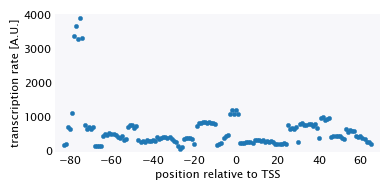

In [13]:
x = process_sequence(df_seqs[df_seqs['promoter'] == 'dgoRp']['sequence'].values[0][27:187], return_TSS=True)
positions = [y[0] - 115 - len("AGTGCCATGTTATCCCTGAATCTAGT") for y in x]
rates = [y[1] for y in  x]

fig, ax = plt.subplots(figsize=(4,2))
ax.scatter(positions, rates,s=10)
ax.set_ylabel("transcription rate [A.U.]")
ax.set_xlabel("position relative to TSS")
fig.tight_layout()
fig.savefig("dgoR_predicted_TSS.pdf")

In [14]:
max_rates = []
promoters = []
for (promoter,), gdf in df_seqs.groupby(['promoter']):
    p = regseq2.promoter_calculator.Promoter_Calculator()
    control_seq = gdf["sequence"].values[0]#[26:186]
    x = process_sequence(control_seq)
    
    max_rates.append(np.max(x))
    promoters.append(promoter)

In [15]:
print("Maximum Transcription Rate \n", promoters[np.argmax(max_rates)], '\n', np.max(max_rates))
print()
print("Mean Transcription Rate \n", np.mean(max_rates))
print()
print("Median Transcription Rate \n", np.median(max_rates))
print()
print("Confidence Interval\n", calculate_confidence_interval(max_rates, confidence=0.95))

Maximum Transcription Rate 
 marRp 
 26362.24576043728

Mean Transcription Rate 
 3913.883995015

Median Transcription Rate 
 3280.900764791127

Confidence Interval
 (np.float64(3429.3530162286793), np.float64(4398.414973801321))


Text(0.5, 0, 'maximum transcription\nrate from each promoter')

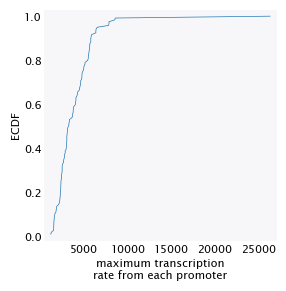

In [16]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(np.sort(max_rates), np.arange(1, len(max_rates)+1)/len(max_rates))
ax.set_ylabel("ECDF")
ax.set_xlabel("maximum transcription\nrate from each promoter")

Run random sequences through.

Text(0.5, 0, 'transcription rate from random sequences [A.U.]')

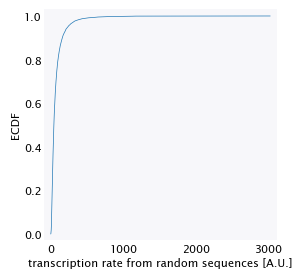

In [17]:
random_rates = np.zeros(10000)
for i in range(10000):
    seq = "".join(np.random.choice(['A', 'C', 'G', 'T'], 78))
    p = regseq2.promoter_calculator.Promoter_Calculator()
    p.run(seq)
    output = p.output()
    random_rates[i] = output['Forward_Predictions_per_TSS'][58]['Tx_rate']

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(np.sort(random_rates), np.arange(1, len(random_rates)+1)/len(random_rates))
ax.set_ylabel("ECDF")
ax.set_xlabel("transcription rate from random sequences [A.U.]")

In [18]:
print("Maximum Transcription Rate\n", np.max(random_rates))
print()
print("Mean Transcription Rate \n", np.mean(random_rates))
print()
print("Median Transcription Rate \n", np.median(random_rates))
print()
print("Confidence Interval\n", calculate_confidence_interval(random_rates, confidence=0.95))

Maximum Transcription Rate
 3014.704707233696

Mean Transcription Rate 
 77.54378278460904

Median Transcription Rate 
 46.87299939682865

Confidence Interval
 (np.float64(75.47762914261737), np.float64(79.6099364266007))


## Run on all promoters from experiment

In [19]:
# Example: process rows in parallel if possible, or just loop over rows
# Only run on server
if server:
        
    from joblib import Parallel, delayed
    df_out = pd.DataFrame()
    for _, row in tqdm(df_triage.iterrows(), total=len(df_triage)):
        seqs_w, seqs_wo, pos = get_seqs(row['promoter'], row['gc'], row['rep'])
        
        # Parallel processing for sequences with mutation
        x_w = Parallel(n_jobs=20)(
            delayed(process_sequence)(seq, return_TSS=True)
            for seq in seqs_w
        )
        
        # Parallel processing for sequences without mutation
        x_wo = Parallel(n_jobs=20)(
            delayed(process_sequence)(seq, return_TSS=True)
            for seq in seqs_wo
        )

        tss_w = [[_x[0] for _x in x] for x in x_w] 
        rates_w = [[_x[1] for _x in x] for x in x_w] 
        tss_wo = [[_x[0] for _x in x] for x in x_wo] 
        rates_wo = [[_x[1] for _x in x] for x in x_wo] 
        # Compute mean rates across sequences using numpy for efficiency
        mean_rates_w = np.mean(rates_w, axis=0)
        mean_rates_wo = np.mean(rates_wo, axis=0)
        zero_pos = 58 - 26 - 115
        positions = range(zero_pos, zero_pos + len(mean_rates_w))
        _df = pd.DataFrame({"promoter": row['promoter'], "gc": row['gc'], "rep": row['rep'], "pos": positions, "rates_w_mutation": mean_rates_w, "rates_wo_mutation": mean_rates_wo})
        
        df_out = pd.concat([df_out, _df])
        
        fig, ax = plt.subplots(figsize=(6, 4))
        
    
        
        ax.scatter(positions, mean_rates_w, label='with mutation')
        ax.scatter(positions, mean_rates_wo, label='without mutation')
        
        # Plot vertical line at the position
        combined_rates = np.concatenate([mean_rates_w, mean_rates_wo])
        ax.vlines(
            [pos], 
            ymin=np.min(combined_rates), 
            ymax=np.max(combined_rates), 
            color="green", 
            linestyle='--', 
            lw=2
        )
        
        ax.legend(title='sequences')
        ax.set_xlabel("position of TSS (relative to known)")
        ax.set_ylabel("Transcription Rate [A.U.]")
        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        fig.savefig(f"emerging_promoters/{row['promoter']}-{row['gc']}-{row['rep']}_lafleur.pdf")
        plt.close()
        break
        
    #df_out.to_csv("emerging_promoter_tx_rates.csv")

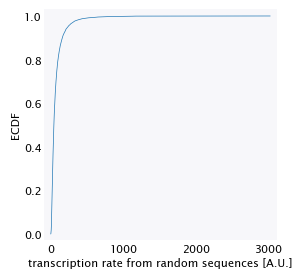

In [20]:
fig

In [21]:
df_experiment = pd.read_csv("emerging_promoter_tx_rates.csv", usecols=[1, 2, 3, 4, 5, 6])
df_experiment.head()

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
0,araBp,29,2,-83,63.938619,66.829667
1,araBp,29,2,-82,111.745962,105.412062
2,araBp,29,2,-81,171.366171,165.896161
3,araBp,29,2,-80,321.923234,289.217685
4,araBp,29,2,-79,384.228453,352.081894


In [22]:
df_experiment[df_experiment['promoter'] == 'elaBp'].sort_values('gc')

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
63773,elaBp,12,2,-82,159.098137,162.652668
63825,elaBp,12,2,-30,888.743895,779.294735
63824,elaBp,12,2,-31,908.990260,808.105521
63823,elaBp,12,2,-32,892.765200,774.907295
63822,elaBp,12,2,-33,828.799113,762.043380
...,...,...,...,...,...,...
52993,elaBp,41,1,15,459.092537,405.722979
52992,elaBp,41,1,14,305.265663,333.114206
52991,elaBp,41,1,13,299.241948,328.009927
52989,elaBp,41,1,11,305.785966,337.725175


In [23]:
df_experiment[df_experiment['promoter'] == 'mglBp'].sort_values('gc')

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
149,mglBp,9,2,-83,114.317172,109.978320
24340,mglBp,9,1,-30,1027.547422,1049.203724
24339,mglBp,9,1,-31,1187.326127,1198.221344
24338,mglBp,9,1,-32,1025.211991,1042.303717
24337,mglBp,9,1,-33,1146.140536,1139.107337
...,...,...,...,...,...,...
66458,mglBp,41,1,-79,446.664566,465.498875
66459,mglBp,41,1,-78,461.279045,479.756749
66460,mglBp,41,1,-77,447.330531,470.688689
40004,mglBp,41,2,-11,485.223021,470.589030


In [24]:
def reverse_complement(dna):
    complements = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return "".join(complements[base] for base in reversed(dna))

def find_loc(promoter):
    with open("../../data/metadata/mg1655_genome.fasta", 'r') as file:
        lines = file.readlines()
    sequence = ''.join(line.strip() for line in lines if not line.startswith('>'))   
    seq = df_seqs.loc[df_seqs['promoter'] == promoter, "sequence"].values[0][26:186]

    loc = sequence.find(seq)
    direction = 1
    if loc == -1:
        loc = sequence.find(reverse_complement(seq))
        direction = -1
    if loc == -1:
        raise Exception("Promoter location not found")
        
    if direction == 1:
        return sequence[loc-115-26:loc-115], sequence[loc+45:loc+(45+40)]
    else:
        return reverse_complement(sequence[loc+115:loc+115+26]), reverse_complement(sequence[loc-45-40:loc-45])

## Run with wild type flanks

In [25]:
# Only run on server
if server: 
    from joblib import Parallel, delayed
    df_out = []
    for _, row in tqdm(df_triage.iterrows(), total=len(df_triage)):
        seqs_w, seqs_wo, pos = get_seqs(row['promoter'], row['gc'], row['rep'])
        pre_sequence, trail_sequence = find_loc(row['promoter'])
        zero_pos = 58 - len(pre_sequence) - 115
        
        # Parallel processing for sequences with mutation
        rates_w = Parallel(n_jobs=40)(
            delayed(process_sequence)(seq, pre_sequence, trail_sequence)
            for seq in seqs_w
        )
        
        # Parallel processing for sequences without mutation
        rates_wo = Parallel(n_jobs=40)(
            delayed(process_sequence)(seq, pre_sequence, trail_sequence)
            for seq in seqs_wo
        )
    
        # Compute mean rates across sequences using numpy for efficiency
        mean_rates_w = np.mean(rates_w, axis=0)
        mean_rates_wo = np.mean(rates_wo, axis=0)
    
        positions = range(zero_pos, zero_pos + len(mean_rates_w))
        _df = pd.DataFrame({"promoter": row['promoter'], "gc": row['gc'], "rep": row['rep'], "pos": positions, "rates_w_mutation": mean_rates_w, "rates_wo_mutation": mean_rates_wo})
        df_out.append(_df)
        
    pd.concat(df_out).to_csv("emerging_promoter_tx_rates_w_gen_flanks.csv")

In [26]:
pre, tail = find_loc("mglBp")

In [27]:
np.max(process_sequence(pre_sequence=pre, trail_sequence=tail, seq=df_seqs[df_seqs['promoter'] == 'mglBp']['sequence'].values[0][26:186]))

np.float64(5443.977450514807)

In [28]:
df_salis = pd.read_csv("emerging_promoter_tx_rates.csv", usecols=[1, 2, 3, 4, 5, 6])
df_salis.head()

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
0,araBp,29,2,-83,63.938619,66.829667
1,araBp,29,2,-82,111.745962,105.412062
2,araBp,29,2,-81,171.366171,165.896161
3,araBp,29,2,-80,321.923234,289.217685
4,araBp,29,2,-79,384.228453,352.081894


In [29]:
def plot_tx_rates(df, promoter, gc, rep, save=False):
    
    sub_df = df[(df['promoter'] == promoter) & (df['gc'] == gc) & (df['rep'] == rep)]
    _, _, pos = get_seqs(promoter, gc, rep)
    gc_descriptive = growth_conditions.loc[growth_conditions.Index == gc, "Condition"].values[0]
    
    fig, ax = plt.subplots(figsize=(6, 3))
    offset = 58
    pre_sequence_length = len("AGTGCCATGTTATCCCTGAATCTAGT")
    zero_pos = offset - pre_sequence_length - 115
    
    
    ax.scatter(
        sub_df['pos'].values, 
        sub_df['rates_wo_mutation'].values, 
        label='without mutation', 
        s=6,
        color="#bec0c2",
    )
    ax.scatter(
        sub_df['pos'].values, 
        sub_df['rates_w_mutation'].values, 
        label='with mutation', 
        s=6,
        color="#ab85ac"
    )
    
    # Plot vertical line at the position
    combined_rates = np.concatenate([sub_df['rates_w_mutation'].values, sub_df['rates_wo_mutation'].values])
    ax.vlines(
        [pos], 
        ymin=np.min(combined_rates), 
        ymax=np.max(combined_rates), 
        color="black", 
        linestyle='--', 
        lw=1
    )
    
    ax.set_xlabel("position of putative TSS (relative to known)")
    ax.set_ylabel("transcription rate [A.U.]")
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(title='sequences',loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True)
    ax.set_title(f"{promoter} in {gc_descriptive}, replicate {rep}")
    if save:
        width_pts = 160
        height_pts = 80.12
        dpi = 100
        
        # Calculate figsize in inches
        width_in = get_pixels(width_pts) / dpi
        height_in = get_pixels(height_pts) / dpi
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.set_figwidth(width_in)
        fig.set_figheight(height_in)
        fig.set_dpi(dpi)
        ax.tick_params(axis='both', labelsize=3)
        ax.set_xlabel("position of TSS (relative to known)", fontsize=6)
        ax.set_ylabel("Transcription Rate [A.U.]", fontsize=6)  
        ax.set_title(f"{promoter} in {gc_descriptive}, replicate {rep}", fontsize=6)
        fig.savefig(f"emerging_promoters/{promoter}-{gc}-{rep}_lafleur.pdf")
    plt.close()
    return sub_df['rates_w_mutation'].values, sub_df['rates_wo_mutation'].values, ax, fig
    

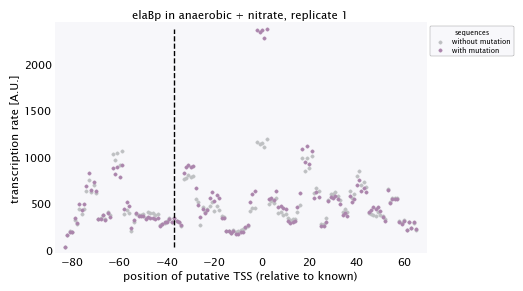

In [30]:
_, _,ax, fig = plot_tx_rates(df_experiment, "elaBp", 41, 1)#, save=True)
#fig.savefig("files/elaB_ana-nit_emerging.pdf")
fig

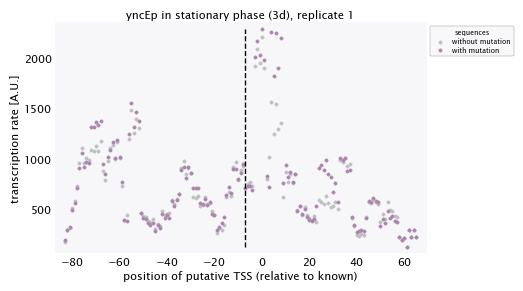

In [31]:
_, _,ax, fig = plot_tx_rates(df_experiment, "yncEp", 8, 1)#, save=True)
#fig.savefig("files/elaB_ana-nit_emerging.pdf")
fig

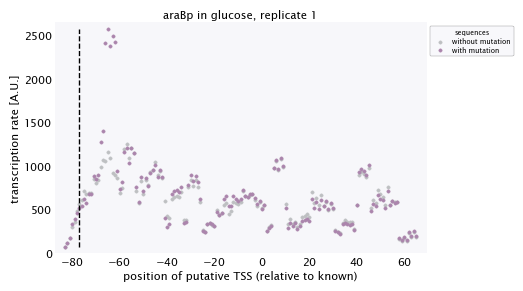

In [32]:
_, _,ax, fig = plot_tx_rates(df_experiment, "araBp", 1, 1)#, save=True)
#fig.savefig("files/araB_glucose_emerging.pdf")
fig

In [33]:
_, _,ax, fig = plot_tx_rates(df_experiment, "araBp", 1, 1)#, save=True)
_, _, ind = get_seqs("araBp", 1, 1)
ind

np.int64(-77)

In [ ]:
_, _,ax, fig = plot_tx_rates(df_experiment, "ompFp", 1, 1)#, save=True)
_, _, ind = get_seqs("araBp", 1, 1)
ind

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
0,araBp,29,2,-83,63.938619,66.829667
1,araBp,29,2,-82,111.745962,105.412062
2,araBp,29,2,-81,171.366171,165.896161
3,araBp,29,2,-80,321.923234,289.217685
4,araBp,29,2,-79,384.228453,352.081894
...,...,...,...,...,...,...
109659,lppp2,10,2,61,113.923212,113.809676
109660,lppp2,10,2,62,271.073689,286.184689
109661,lppp2,10,2,63,211.410507,223.527173
109662,lppp2,10,2,64,275.789971,291.535726


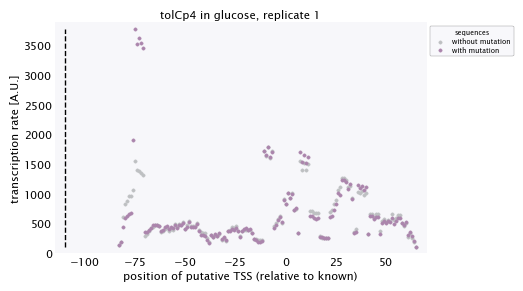

In [62]:
_, _,ax, fig = plot_tx_rates(df_experiment, "tolCp4", 1, 1)#, save=True)
fig.savefig("tolCp4_glucose_emerging.pdf")
fig

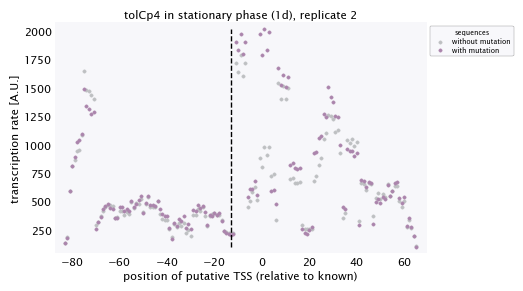

In [37]:
_, _,ax, fig = plot_tx_rates(df_experiment, "tolCp4", 7, 2)#, save=True)
fig.savefig("tolCp4_statphase_emerging.pdf")
fig

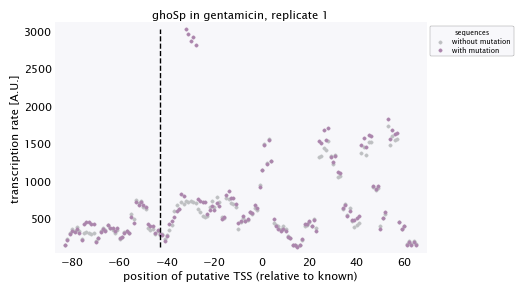

In [40]:
_, _,ax, fig = plot_tx_rates(df_experiment, "ghoSp", 29, 1)#, save=True)
fig.savefig("ghoS_gent_emerging.pdf")
fig

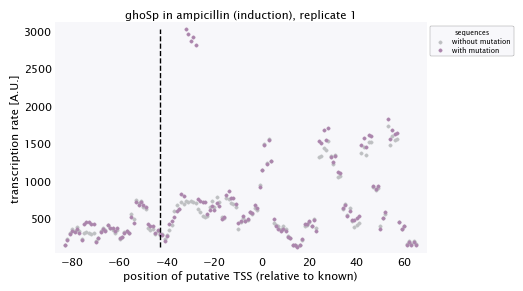

In [42]:
_, _,ax, fig = plot_tx_rates(df_experiment, "ghoSp", 18, 1)#, save=True)
fig.savefig("ghoS_amp_emerging.pdf")
fig

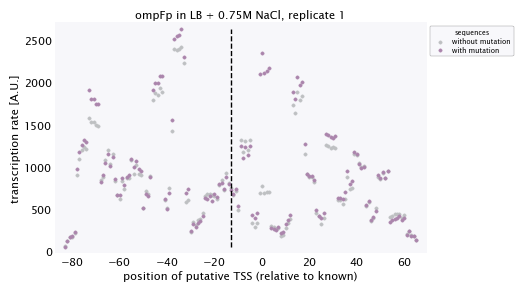

In [ ]:
_, _,ax, fig = plot_tx_rates(df_experiment, "ompFp", 36, 1)#, save=True)
fig.savefig("ompF_salt_emerging.pdf")
fig

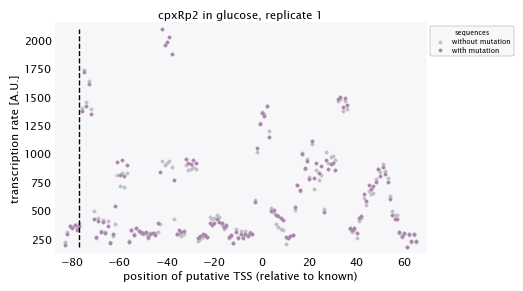

In [59]:
_, _,ax, fig = plot_tx_rates(df_experiment, "cpxRp2", 1, 1)#, save=True)
fig.savefig("cpxRp2_glucose_emerging.pdf")
fig

In [40]:
_, _, ind = get_seqs("xylAp", 3, 1)
ind

np.int64(-68)

In [30]:
df_experiment[df_experiment['promoter'] == 'znuCp']

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation


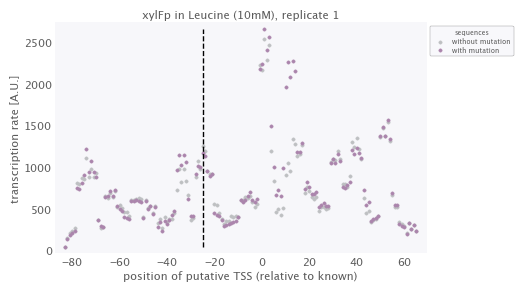

In [29]:
_, _,ax, fig = plot_tx_rates(df_experiment, "xylFp", 21, 1)#, save=True)
#fig.savefig("files/xylA_arabinose_emerging.pdf")
fig

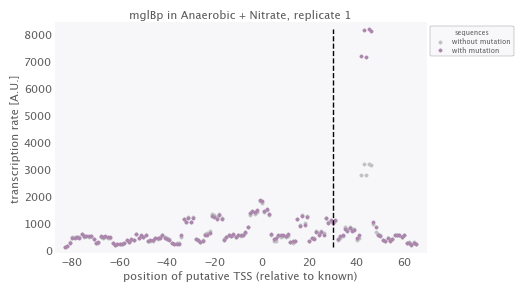

In [38]:
_, _,ax, fig = plot_tx_rates(df_experiment, "mglBp", 41, 1)#, save=True)
fig.savefig("files/mglB_ana-nit_emerging.pdf")
fig

In [42]:
_, _, ind = get_seqs("mglBp", 41, 1)
ind

np.int64(30)

In [129]:
df_seqs[df_seqs['promoter'] == 'araBp']['sequence'].values[0][26:186][115-82:115-70]

'GCTATGCCATAG'

In [128]:
df_seqs[df_seqs['promoter'] == 'araBp']['sequence'].values[0][26:186][115-85:115-70]

'TTTGCTATGCCATAG'

In [ ]:
seq = df_seqs[df_seqs['promoter'] == 'araBp']['sequence'].values[0][26:186]
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
output['Forward_Predictions_per_TSS'][58+ind]

{'promoter_sequence': 'GTTCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGCATTTTTATCCATAAGATTAGCGGATCCTACCT',
 'TSS': 84,
 'UP': 'GTTCCACATTGATTATTTGCACGG',
 'hex35': 'GTCACA',
 'spacer': 'CTTTGCTATGCCATAG',
 'hex10': 'CATTTT',
 'disc': 'TATCCAT',
 'ITR': 'AAGATTAGCGGATCCTACCT',
 'dG_total': np.float64(-2.193919056342406),
 'dG_10': -0.5551477221901369,
 'dG_35': -0.7264913590667282,
 'dG_disc': -0.1441943360313018,
 'dG_ITR': np.float64(-0.013194832348429041),
 'dG_ext10': -0.139301362120528,
 'dG_spacer': -0.008999999999993236,
 'dG_UP': np.float64(0.3517690091730447),
 'dG_bind': np.float64(-1.0781714342043414),
 'Tx_rate': 1521.4168009441235,
 'UP_position': [24, 48],
 'hex35_position': [49, 55],
 'spacer_position': [55, 71],
 'hex10_position': [71, 77],
 'disc_position': [77, 84]}

In [75]:
seq = df_seqs[df_seqs['promoter'] == 'araBp']['sequence'].values[0][26:186]
_seq = list(seq)
_seq[115-77] = 'A'
seq = "".join(_seq)
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
output['Forward_Predictions_per_TSS'][58+ind]


{'promoter_sequence': 'CTGAATCTAGTTCCACATTGATTATTTGCACGGCGTCACACTTTGCTATACCATAGCATTTTTATCCATAAGATTAGCGGA',
 'TSS': 76,
 'UP': 'CTGAATCTAGTTCCACATTGATTA',
 'hex35': 'TTGCAC',
 'spacer': 'GGCGTCACACTTTGCTA',
 'hex10': 'TACCAT',
 'disc': 'AGCATTT',
 'ITR': 'TTATCCATAAGATTAGCGGA',
 'dG_total': np.float64(-2.5345428269596426),
 'dG_10': -1.2931618409214267,
 'dG_35': -0.8570227747378614,
 'dG_disc': 0.1658800645338869,
 'dG_ITR': np.float64(-0.010555865878743222),
 'dG_ext10': 0.18814810202386284,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.32292794177896367),
 'dG_bind': np.float64(-1.7315085718564527),
 'Tx_rate': 2656.412192013248,
 'UP_position': [15, 39],
 'hex35_position': [40, 46],
 'spacer_position': [46, 63],
 'hex10_position': [63, 69],
 'disc_position': [69, 76]}

### tolCp4

In [85]:
seq = df_seqs[df_seqs['promoter'] == 'tolCp4']['sequence'].values[0][26:186]
_seq = list(seq)
_seq[115-110] = 'T'
seq = "".join(_seq)
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
print(seq[0:20])
output['Forward_Predictions_per_TSS'][58+ind]


-75
TTTGATTGCCGTTTGAGCAG


{'promoter_sequence': 'ATGTTATCCCTGAATCTAGTTTTGATTGCCGTTTGAGCAGTCATGTGTTAAATTGAGGCACATTAACGCCCTATGGCACG',
 'TSS': 66,
 'UP': 'ATGTTATCCCTGAATCTAGTTTTG',
 'hex35': 'TTGCCG',
 'spacer': 'TTTGAGCAGTCATGTGT',
 'hex10': 'TAAATT',
 'disc': 'GAGGCA',
 'ITR': 'CATTAACGCCCTATGGCACG',
 'dG_total': np.float64(-2.8262646699721277),
 'dG_10': -1.2903355042370541,
 'dG_35': -0.864756034536041,
 'dG_disc': 0.20430148488065647,
 'dG_ITR': np.float64(0.022619712597306937),
 'dG_ext10': -0.2144031377586821,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.3670672628400101),
 'dG_bind': np.float64(-2.0948274136917577),
 'Tx_rate': 4281.4710447186235,
 'UP_position': [6, 30],
 'hex35_position': [31, 37],
 'spacer_position': [37, 54],
 'hex10_position': [54, 60],
 'disc_position': [60, 66]}

In [86]:
seq = df_seqs[df_seqs['promoter'] == 'tolCp4']['sequence'].values[0][26:186]
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
print(seq[0:20])
output['Forward_Predictions_per_TSS'][58+ind]

TTTGACTGCCGTTTGAGCAG


{'promoter_sequence': 'ATGTTATCCCTGAATCTAGTTTTGACTGCCGTTTGAGCAGTCATGTGTTAAATTGAGGCACATTAACGCCCTATGGCACG',
 'TSS': 66,
 'UP': 'ATGTTATCCCTGAATCTAGTTTTG',
 'hex35': 'CTGCCG',
 'spacer': 'TTTGAGCAGTCATGTGT',
 'hex10': 'TAAATT',
 'disc': 'GAGGCA',
 'ITR': 'CATTAACGCCCTATGGCACG',
 'dG_total': np.float64(-2.22143652541989),
 'dG_10': -1.2903355042370541,
 'dG_35': -0.25993287626768197,
 'dG_disc': 0.20430148488065647,
 'dG_ITR': np.float64(0.022619712597306937),
 'dG_ext10': -0.2144031377586821,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.3670722491238894),
 'dG_bind': np.float64(-1.4899992691395196),
 'Tx_rate': 1591.4834320892583,
 'UP_position': [6, 30],
 'hex35_position': [31, 37],
 'spacer_position': [37, 54],
 'hex10_position': [54, 60],
 'disc_position': [60, 66]}

### cpxRp2

In [89]:
seq = df_seqs[df_seqs['promoter'] == 'cpxRp2']['sequence'].values[0][26:186]
_seq = list(seq)
_seq[115-77] = 'T'
seq = "".join(_seq)
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
print(seq[34:48])
output['Forward_Predictions_per_TSS'][58+ind]


-42
CAGGTTGCAAACAT


{'promoter_sequence': 'AACGATAGAGAGTTTACGATTCAGGTTGCAAACATGCGTCAGGGGGTGTAAAACAACGTAAAGTCATGGATTAGCGACGT',
 'TSS': 99,
 'UP': 'AACGATAGAGAGTTTACGATTCAG',
 'hex35': 'TTGCAA',
 'spacer': 'ACATGCGTCAGGGGGTG',
 'hex10': 'TAAAAC',
 'disc': 'AACGTA',
 'ITR': 'AAGTCATGGATTAGCGACGT',
 'dG_total': np.float64(-2.6127156480482103),
 'dG_10': -0.7187525931928276,
 'dG_35': -1.0762792738845612,
 'dG_disc': 0.03794051524303827,
 'dG_ITR': np.float64(-0.045993415614524094),
 'dG_ext10': -0.07964961793745078,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.32077719109643976),
 'dG_bind': np.float64(-1.6463042939183907),
 'Tx_rate': 3018.8745957849915,
 'UP_position': [39, 63],
 'hex35_position': [64, 70],
 'spacer_position': [70, 87],
 'hex10_position': [87, 93],
 'disc_position': [93, 99]}

In [90]:
seq = df_seqs[df_seqs['promoter'] == 'cpxRp2']['sequence'].values[0][26:186]
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
print(seq[33:48])
output['Forward_Predictions_per_TSS'][58+ind]


-42
TCAGGCTGCAAACAT


{'promoter_sequence': 'AACGATAGAGAGTTTACGATTCAGGCTGCAAACATGCGTCAGGGGGTGTAAAACAACGTAAAGTCATGGATTAGCGACGT',
 'TSS': 99,
 'UP': 'AACGATAGAGAGTTTACGATTCAG',
 'hex35': 'CTGCAA',
 'spacer': 'ACATGCGTCAGGGGGTG',
 'hex10': 'TAAAAC',
 'disc': 'AACGTA',
 'ITR': 'AAGTCATGGATTAGCGACGT',
 'dG_total': np.float64(-2.0078875034959722),
 'dG_10': -0.7187525931928276,
 'dG_35': -0.47145611561620226,
 'dG_disc': 0.03794051524303827,
 'dG_ITR': np.float64(-0.045993415614524094),
 'dG_ext10': -0.07964961793745078,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.32078217738031906),
 'dG_bind': np.float64(-1.0414761493661524),
 'Tx_rate': 1122.1584480113459,
 'UP_position': [39, 63],
 'hex35_position': [64, 70],
 'spacer_position': [70, 87],
 'hex10_position': [87, 93],
 'disc_position': [93, 99]}

ghoSp


In [55]:
seq = df_seqs[df_seqs['promoter'] == 'ghoSp']['sequence'].values[0][26:186]
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
print(seq[33:48])
output['Forward_Predictions_per_TSS'][58+ind]


53
TCCCAAGTCATCCCC


{'promoter_sequence': 'TTTTGCGTCCCCAGAGCGTTTAATATTGATAGGAGTCATATTATGGAAGGTAACTCATCAGACCGGAAAGCACATCCGGTG',
 'TSS': 194,
 'UP': 'TTTTGCGTCCCCAGAGCGTTTAAT',
 'hex35': 'TTGATA',
 'spacer': 'GGAGTCATATTATGGAAG',
 'hex10': 'GTAACT',
 'disc': 'CATCAG',
 'ITR': 'ACCGGAAAGCACATCCGGTG',
 'dG_total': np.float64(-2.4227696820200966),
 'dG_10': -0.9606590530884109,
 'dG_35': -0.9057825190841922,
 'dG_disc': -0.06688516612075936,
 'dG_ITR': np.float64(-0.04410843956474856),
 'dG_ext10': 0.0610364204005321,
 'dG_spacer': 0.116800000000012,
 'dG_UP': np.float64(0.3351875291958044),
 'dG_bind': np.float64(-1.3534176225762546),
 'Tx_rate': 2212.4296303685283,
 'UP_position': [133, 157],
 'hex35_position': [158, 164],
 'spacer_position': [164, 182],
 'hex10_position': [182, 188],
 'disc_position': [188, 194]}

In [63]:
seq = df_seqs[df_seqs['promoter'] == 'ghoSp']['sequence'].values[0][26:186]
_seq = list(seq)
print(_seq[115-43])
_seq[115-43] = 'A'
seq = "".join(_seq)
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
output['Forward_Predictions_per_TSS'][58+ind]


C
-32


{'promoter_sequence': 'CGTTTTTTTGTCCCAAGTCATCCCCTTTACTGAGCAAAAAAAAGAATATATCCTATATGAGAATCATCAATCGGGGTTAA',
 'TSS': 109,
 'UP': 'CGTTTTTTTGTCCCAAGTCATCCC',
 'hex35': 'TTTACT',
 'spacer': 'GAGCAAAAAAAAGAATA',
 'hex10': 'TATCCT',
 'disc': 'ATATGA',
 'ITR': 'GAATCATCAATCGGGGTTAA',
 'dG_total': np.float64(-2.8259638872664823),
 'dG_10': -1.192657582761927,
 'dG_35': -0.8766681063993773,
 'dG_disc': -0.060202924695229726,
 'dG_ITR': np.float64(-0.005654928149326685),
 'dG_ext10': -0.1710940037718414,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.5310721122695444),
 'dG_bind': np.float64(-1.801747580663592),
 'Tx_rate': 4279.364455238491,
 'UP_position': [49, 73],
 'hex35_position': [74, 80],
 'spacer_position': [80, 97],
 'hex10_position': [97, 103],
 'disc_position': [103, 109]}

In [62]:
seq = df_seqs[df_seqs['promoter'] == 'ghoSp']['sequence'].values[0][26:186]
pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT"
trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper()
p = regseq2.promoter_calculator.Promoter_Calculator()
# Concatenate outside the inner loop
full_seq = pre_sequence + seq + trail_sequence
p.run(full_seq)
output = p.output()
# Use list comprehension to extract Tx_rate values
#ind = np.argmax([output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']])
print(output['Forward_Predictions_per_TSS'][58+ind]['TSS']-115-len(pre_sequence))
print(seq[34:48])
output['Forward_Predictions_per_TSS'][58+ind]


-32
CCCAAGTCATCCCC


{'promoter_sequence': 'CGTTTTTTTGTCCCAAGTCATCCCCTTTACTGAGCAAAAAAAAGAATATCTCCTATATGAGAATCATCAATCGGGGTTAA',
 'TSS': 109,
 'UP': 'CGTTTTTTTGTCCCAAGTCATCCC',
 'hex35': 'TTTACT',
 'spacer': 'GAGCAAAAAAAAGAATA',
 'hex10': 'TCTCCT',
 'disc': 'ATATGA',
 'ITR': 'GAATCATCAATCGGGGTTAA',
 'dG_total': np.float64(-1.8560880754890428),
 'dG_10': -0.2227817709844873,
 'dG_35': -0.8766681063993773,
 'dG_disc': -0.060202924695229726,
 'dG_ITR': np.float64(-0.005654928149326685),
 'dG_ext10': -0.1710940037718414,
 'dG_spacer': -0.09239999999999071,
 'dG_UP': np.float64(0.5310721122695444),
 'dG_bind': np.float64(-0.8318717688861522),
 'Tx_rate': 875.3576011871241,
 'UP_position': [49, 73],
 'hex35_position': [74, 80],
 'spacer_position': [80, 97],
 'hex10_position': [97, 103],
 'disc_position': [103, 109]}

In [53]:
output

{'organism': 'Escherichia coli str. K-12 substr. MG1655',
 'sigmaLevels': {'70': 1.0,
  '19': 0.0,
  '24': 0.0,
  '28': 0.0,
  '32': 0.0,
  '38': 0.0,
  '54': 0.0},
 'K': 42.0,
 'beta': 1.636217004872062,
 'sequence': 'AGTGCCATGTTATCCCTGAATCTAGTGCACAAAGAATGGGCAGAGAGCGCGTTTTTTTGTCCCAAGTCATCCCCTTTACTGAGCAAAAAAAAGAATATCTCCTATATGAGAATCATCAATCGGGGTTAATAAGTTTTGCGTCCCCAGAGCGTTTAATATTGATAGGAGTCATATTATGGAAGGTAACTCATCAGACCGGAAAGCACATCCGGTGACAGCTGGGCCC',
 'TSS_range': [0, 226],
 'Forward_Predictions_per_TSS': {58: {'promoter_sequence': 'AGTGCCATGTTATCCCTGAATCTAGTGCACAAAGAATGGGCAGAGAGCGCGTTTTTTTGTCCCAAGTCATCCCCTTTA',
   'TSS': 58,
   'UP': 'AGTGCCATGTTATCCCTGAATCTA',
   'hex35': 'TGCACA',
   'spacer': 'AAGAATGGGCAGAGA',
   'hex10': 'GCGCGT',
   'disc': 'TTTTTT',
   'ITR': 'GTCCCAAGTCATCCCCTTTA',
   'dG_total': np.float64(-0.7627269994333459),
   'dG_10': -0.22957944752798204,
   'dG_35': -0.6260976284949558,
   'dG_disc': 0.15168390811051485,
   'dG_ITR': np.float64(0.09462579769873415),
   'dG_ex

In [59]:
df_list = []

for (promoter, gc, rep), gdf in df_salis.groupby(['promoter', 'gc', 'rep']):
    x_w = gdf['rates_w_mutation'].values
    x_wo = gdf['rates_wo_mutation'].values
    np.sum(x_w) / np.sum(x_wo)
    np.max(x_w) / np.max(x_wo)
    pos = gdf['pos'].values[np.argmax(gdf['rates_w_mutation'].values)]
    df_list.append(pd.DataFrame({"promoter": [promoter], 
                                 "rep": [rep], 
                                 "gc": [gc], 
                                 "pos": [pos], 
                                 "integral_ratio": [np.sum(x_w) / np.sum(x_wo)],
                                 "max_ratio": [np.max(x_w) / np.max(x_wo)]
                                }))

df_salis_sum = pd.concat(df_list)
df_salis_sum.head()

,promoter,rep,gc,pos,integral_ratio,max_ratio
0,TSS_18061_regulondb,2,5,-19,1.106745,1.864645
0,TSS_18061_regulondb,2,41,-19,1.106745,1.864645
0,TSS_4655_regulondb,2,29,-21,1.039122,1.056007
0,aceBp,1,25,1,1.007481,1.044802
0,araBp,1,1,-65,1.085298,2.065014


In [60]:
df_salis_sum[(df_salis_sum['max_ratio'] > 1.5) & (
             (df_salis_sum['pos'] > 10) |
             (df_salis_sum['pos'] < -10) )
].groupby(
    ['promoter', 'pos']
).apply(
    len, include_groups=False
).reset_index(
    name='num_conditions'
).sort_values(
    'num_conditions',
    ascending=False
).reset_index(
    drop=True
)

,promoter,pos,num_conditions
0,tolCp4,-75,51
1,xylAp,-52,51
2,araBp,-65,45
3,yadN_predicted,-60,27
4,lppp2,-50,24
5,mglBp,45,24
6,xdhAp1,25,21
7,ghoSp,-32,13
8,tolCp3,-63,12
9,mhpRp1,19,11


In [94]:
df_salis_sum[df_salis_sum['promoter'] == 'mglBp']

,promoter,rep,gc,pos,integral_ratio,max_ratio
0,mglBp,1,9,45,1.233089,2.568291
0,mglBp,2,9,45,1.233089,2.568291
0,mglBp,1,11,45,1.233089,2.568291
0,mglBp,2,11,45,1.137171,1.067657
0,mglBp,2,13,45,1.233089,2.568291
0,mglBp,2,15,45,1.233089,2.568291
0,mglBp,1,16,45,1.233089,2.568291
0,mglBp,2,16,45,1.233089,2.568291
0,mglBp,2,17,45,1.233089,2.568291
0,mglBp,1,21,45,1.137171,1.067657


### Run on all wild type promoters

In [64]:
def single_base_mutations(dna_sequence):
    # Define the set of possible nucleotides
    nucleotides = ['A', 'C', 'G', 'T']
    mutations = []
    mutation_list = []
    wt_list = []
    position_list = []
    
    # Loop over each position in the sequence
    for i, base in enumerate(dna_sequence):
        # Loop over each nucleotide to create a mutation
        for nt in nucleotides:
            # Only mutate if the nucleotide is different from the original
            if nt != base:
                mutated_sequence = dna_sequence[:i] + nt + dna_sequence[i+1:]
                mutations.append(mutated_sequence)
                position_list.append(i)
                wt_list.append(base)
                mutation_list.append(nt)
    return mutations, position_list, wt_list, mutation_list

In [68]:
df_promoters = pd.read_csv('../../data/metadata/promoter_list.csv')
df_promoters.dropna(subset='tss', inplace=True)
df_promoters.head()
df_promoters = df_promoters[df_promoters['promoter'] == 'mglBp']
df_promoters

,TU_ID,promoter_ID,genes,direction,gene_position,promoter,tss,evidence
225,TU00168,PM00231,"[""mglA"", ""mglC"", ""mglB""]",-,"[2.239289e6, 2.237753e6, 2.240348e6]",mglBp,2240566.0,"Any[""COMP"", ""EXP"", ""COMP""]"


In [70]:
if server:
    def process_sequence_filtered(sequence):
        p = regseq2.promoter_calculator.Promoter_Calculator()
        # Concatenate outside the inner loop
        full_seq = sequence
        p.run(full_seq)
        output = p.output()
        # Use list comprehension to extract Tx_rate values
        tx_rates = [output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']]
        positions = [output['Forward_Predictions_per_TSS'][key]['TSS'] for key in output['Forward_Predictions_per_TSS']]
        ind = np.argmax(tx_rates)
        return positions[ind], tx_rates[ind]
    
    def single_base_mutations(dna_sequence):
        # Define the set of possible nucleotides
        nucleotides = ['A', 'C', 'G', 'T']
        mutations = []
        mutation_list = []
        wt_list = []
        position_list = []
        
        # Loop over each position in the sequence
        for i, base in enumerate(dna_sequence):
            # Loop over each nucleotide to create a mutation
            for nt in nucleotides:
                # Only mutate if the nucleotide is different from the original
                if nt != base:
                    mutated_sequence = dna_sequence[:i] + nt + dna_sequence[i+1:]
                    mutations.append(mutated_sequence)
                    position_list.append(i)
                    wt_list.append(base)
                    mutation_list.append(nt)
        return mutations, position_list, wt_list, mutation_list
    
    from joblib import Parallel, delayed
    import copy
    
    df_promoters = pd.read_csv('../../data/metadata/promoter_list.csv')
    df_promoters.dropna(subset='tss', inplace=True)
    df_promoters.head()
    
    results = []
    wt_results = []
    
    for row in tqdm(df_promoters.itertuples(index=False), total=len(df_promoters)):
        tss, promoter, direction = row.tss, row.promoter, row.direction
        #tss, promoter, direction = row[['tss', 'promoter', 'direction']]
        tss = int(tss)
        if direction == '+':
            promoter_seq = sequence[tss-(115+26):tss+(45+40)]
        else:
            promoter_seq = reverse_complement(sequence[tss-(45+40):tss+(115+26)])
    
        
        sequence_list, position_list, wt_list, mutation_list = single_base_mutations(promoter_seq)
        
        output = Parallel(n_jobs=48)(
            delayed(process_sequence_filtered)(seq)
            for seq in sequence_list
        )
        pos = np.array([x[0] for x in output]) - (115+26)
        rates_w = np.array([x[1] for x in output])
        
        
        # Parallel processing for sequences without mutation
        pos_wt, rate_wt = process_sequence_filtered(promoter_seq)
        
        results.append({
            "promoter": promoter,
            "tss": tss,
            "rates_w_mutation": rates_w,
            "positions": pos,
            "mutation_pos": position_list,
            "wt_base": wt_list,
            "mutation_list": mutation_list
        })
        wt_results.append({
            "promoter": promoter,
            "position": pos_wt,
            "rate": rate_wt
        })
    
    df_out_all = pd.DataFrame(results)
    df_wt_all = pd.DataFrame(wt_results)
    
    
    df_out_all.to_csv("emerging_promoter_tx_rates_all_promoters.csv")
    df_wt_all.to_csv("dwt_all.csv")

In [79]:
import ast

def parse_input(s):
    return np.fromstring(s.strip('[]'), sep=' ')

def parse_input_comma(s):
    return np.fromstring(s.strip('[]'), sep=', ')

df_out_all = pd.read_csv(
    "files/out_all.csv",
    sep=",",
    converters={
        "rates_w_mutation": parse_input,
        "positions": parse_input,
        "wt_base": ast.literal_eval,
        "mutation_pos": parse_input_comma,
        "mutation_list": ast.literal_eval,
    },
    index_col=0
)
df_wt_all = pd.read_csv("files/dwt_all.csv", index_col=0)
df_wt_all['position'] -= 115+26

Text(0.5, 0, 'predicted transcription rates')

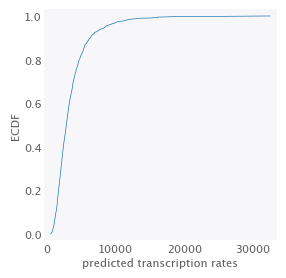

In [80]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(np.sort(df_wt_all['rate'].values), np.arange(1, len(df_wt_all)+1)/len(df_wt_all))
ax.set_ylabel('ECDF')
ax.set_xlabel('predicted transcription rates')

Text(0.5, 0, 'predicted TSS')

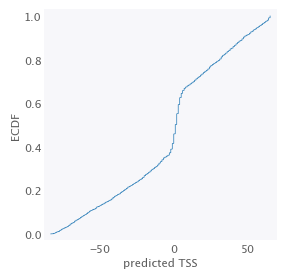

In [81]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(np.sort(df_wt_all['position'].values), np.arange(1, len(df_wt_all)+1)/len(df_wt_all))
ax.set_ylabel('ECDF')
ax.set_xlabel('predicted TSS')

In [82]:
df_wt_all

,promoter,position,rate
0,yggNp1,45,1724.179030
1,adap,-32,1473.641160
2,cstAp2,-23,3583.792782
3,yjaZp,-69,3380.459260
4,fadRp2,33,5505.239328
...,...,...,...
4036,sppAp6,10,2896.475294
4037,alsEp2,0,2201.556381
4038,yfjIp3,63,3969.116583
4039,yhiJp6,-70,3376.369504


Text(0.5, 0, 'position of predicted\nTSS relative to annotated TSS')

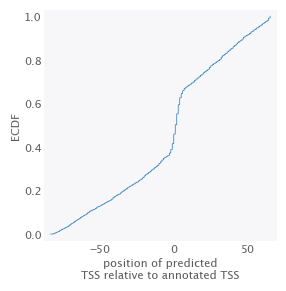

In [88]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(np.sort(df_wt_all['position'].values), np.arange(1, len(df_wt_all)+1)/len(df_wt_all))
ax.set_ylabel('ECDF')
ax.set_xlabel('position of predicted\nTSS relative to annotated TSS')

In [85]:
promoter_list = []
rate_mut_list = []
tss_list = []
mutation_pos_list = []
wt_base_list = []
mutation_list = []


for (_, row), (__, wt_row)  in zip(df_out_all.iterrows(), df_wt_all.iterrows()):
    promoter = row['promoter']
    ind = np.argmax(row['rates_w_mutation'])
    rate = row['rates_w_mutation'][ind]
    tss = row['positions'][ind]
    mut_pos = row['mutation_pos'][ind] - (115+26)
    wt_base = row['wt_base'][ind]
    mutation = row['mutation_list'][ind]
    
    wt_base_list.append(wt_base)
    mutation_list
    rate_mut_list.append(rate)
    tss_list.append(tss)
    mutation_list.append(mutation)
    
df_processed = copy.deepcopy(df_wt_all)
df_processed['rate_mutated'] = rate_mut_list
df_processed['position'] = df_wt_all['position']
df_processed['wt_base'] = wt_base_list
df_processed['mut_tss'] = tss_list
df_processed['mutated_base'] = mutation_list
df_processed['dist_new_tss'] = df_processed['position'] - df_processed['mut_tss']
df_processed['difference'] = df_processed['rate_mutated'] - df_processed['rate']



In [86]:
df_filtered = df_processed[df_processed['rate'] < 2000]

In [91]:
df_processed[df_processed['promoter'] == 'xylAp']

,promoter,position,rate,rate_mutated,wt_base,mut_tss,mutated_base,dist_new_tss,difference
1232,xylAp,-53,4329.32983,10935.350256,A,-53.0,T,0.0,6606.020426


In [96]:
df_processed[df_processed['promoter'] == 'mglBp']

,promoter,position,rate,rate_mutated,wt_base,mut_tss,mutated_base,dist_new_tss,difference
214,mglBp,46,6390.994536,16142.859629,A,46.0,T,0.0,9751.865093


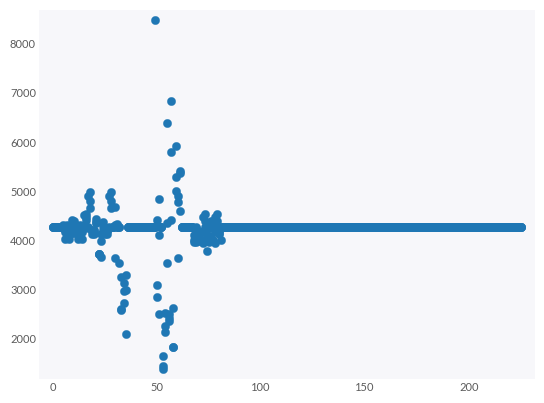

In [158]:
fig, ax = plt.subplots()
_df = df_out_all[df_out_all['promoter'] == 'dgoRp']

ax.scatter(_df['mutation_pos'].values[0], _df['rates_w_mutation'].values[0])


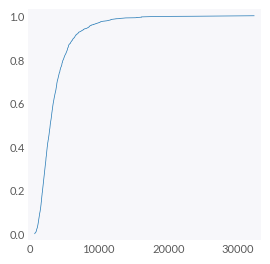

In [93]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(np.sort(df_processed['rate'].values), np.arange(1, len(df_processed)+1)/len(df_processed), label='>10')

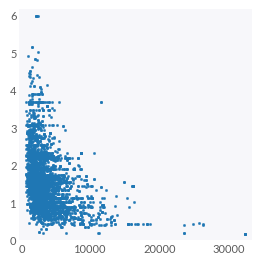

In [110]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(df_processed['rate'].values, df_processed['difference']/df_processed['rate'].values, s=3)

In [99]:
df_processed.iloc[df_processed['rate_mutated'].argmax()]

promoter               bdcAp
position                 -12
rate            11497.584283
rate_mutated    53847.625481
wt_base                    G
mut_tss                -12.0
mutated_base               A
dist_new_tss             0.0
difference      42350.041198
Name: 672, dtype: object

### Promoters with TSS in a different spot

In [86]:
df_filter = df_processed[np.abs(df_processed['position']) > 10]
df_filter

,promoter,position,rate,rate_mutated,wt_base,mut_tss,mutated_base,dist_new_tss,difference
0,yggNp1,45,1724.179030,5576.140431,G,45.0,A,0.0,3851.961400
1,adap,-32,1473.641160,3677.766695,G,3.0,T,-35.0,2204.125535
2,cstAp2,-23,3583.792782,7278.955736,A,-22.0,T,-1.0,3695.162954
3,yjaZp,-69,3380.459260,8217.701130,T,-69.0,A,0.0,4837.241870
4,fadRp2,33,5505.239328,9506.883664,G,33.0,A,0.0,4001.644337
...,...,...,...,...,...,...,...,...,...
4034,rplYp3,20,2728.411425,7068.548942,G,20.0,A,0.0,4340.137517
4035,yhaIp11,59,5593.241055,11815.092055,A,59.0,C,0.0,6221.851001
4038,yfjIp3,63,3969.116583,9627.282311,G,4.0,T,59.0,5658.165728
4039,yhiJp6,-70,3376.369504,7721.641258,A,-1.0,G,-69.0,4345.271754


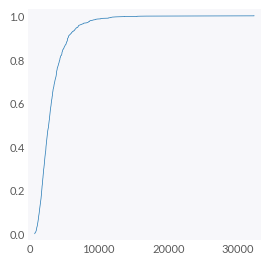

In [87]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(np.sort(df_filter['rate'].values), np.arange(1, len(df_filter)+1)/len(df_filter), label='>10')

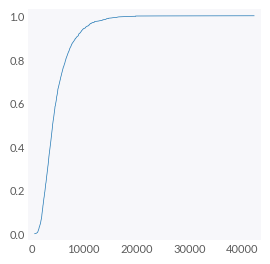

In [88]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(np.sort(df_filter['difference'].values), np.arange(1, len(df_filter)+1)/len(df_filter), label='>10')

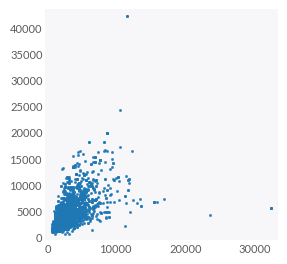

In [92]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(df_filter['rate'].values, df_filter['difference'].values, s=3)

Text(0.5, 0, 'Tx rate')

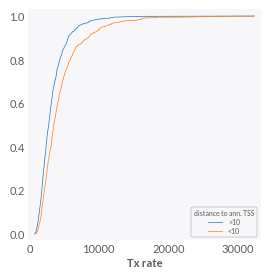

In [79]:
fig, ax = plt.subplots(figsize=(3, 3))
_df = df_processed[np.abs(df_processed['position']) > 10]
ax.plot(np.sort(_df['rate'].values), np.arange(1, len(_df)+1)/len(_df), label='>10')
_df = df_processed[np.abs(df_processed['position']) < 10]
ax.plot(np.sort(_df['rate'].values), np.arange(1, len(_df)+1)/len(_df), label='<10')
ax.legend(title='distance to ann. TSS')
ax.set_xlabel('Tx rate')

Text(0.5, 0, 'diff. Tx rate')

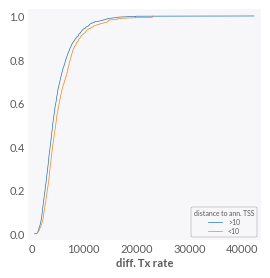

In [80]:
fig, ax = plt.subplots(figsize=(3, 3))
_df = df_processed[np.abs(df_processed['position']) > 10]
ax.plot(np.sort(_df['difference'].values), np.arange(1, len(_df)+1)/len(_df), label='>10')
_df = df_processed[np.abs(df_processed['position']) < 10]
ax.plot(np.sort(_df['difference'].values), np.arange(1, len(_df)+1)/len(_df), label='<10')
ax.legend(title='distance to ann. TSS')
ax.set_xlabel('diff. Tx rate')

In [60]:
print(np.median(df_processed['difference'].values))
print(np.mean(df_processed['difference'].values))
print(np.min(df_processed['difference'].values))
print(np.max(df_processed['difference'].values))

4148.524887560894
4940.0649082546
516.9314240975827
42350.04119781427


In [180]:
df_processed[df_processed['promoter'] == 'mhpRp2']

,promoter,position,rate,rate_mutated,wt_base,mut_tss,mutated_base,dist_new_tss,difference
2250,mhpRp2,19,2671.793314,10979.892818,T,12.0,A,7.0,8308.099503


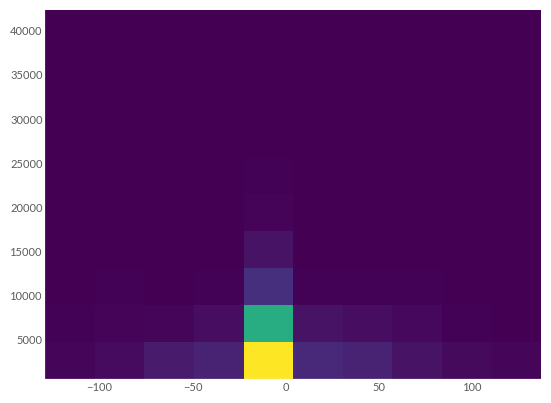

In [69]:
fig, ax = plt.subplots()
ax.hist2d(df_processed['dist_new_tss'].values, df_processed['difference'].values);

In [48]:
display(df_processed.groupby(['wt_base', 'mutated_base'])['difference'].agg('median').reset_index())
display(df_processed.groupby(['wt_base'])['difference'].agg('median').reset_index())
display(df_processed.groupby(['mutated_base'])['difference'].agg('median').reset_index())

,wt_base,mutated_base,difference
0,A,C,5029.352920
1,A,G,5331.091643
2,A,T,4257.064706
3,C,A,3927.015631
4,C,G,3840.341523
5,C,T,3889.207456
6,G,A,3730.642752
7,G,C,3433.444612
8,G,T,3987.035331
9,T,A,4618.887207


,wt_base,difference
0,A,4477.874668
1,C,3866.192958
2,G,3879.925563
3,T,4567.749907


,mutated_base,difference
0,A,4139.452489
1,C,4206.062113
2,G,4548.215143
3,T,4075.659946


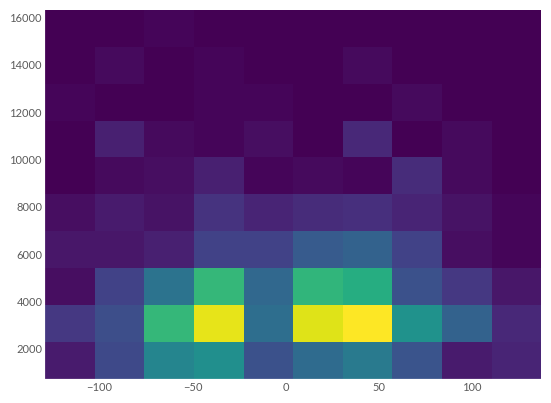

In [70]:
_df = df_processed[np.abs(df_processed['dist_new_tss']) > 10]
fig, ax = plt.subplots()
ax.hist2d(_df['dist_new_tss'].values, _df['difference'].values);

NameError: name 'diff_arr' is not defined

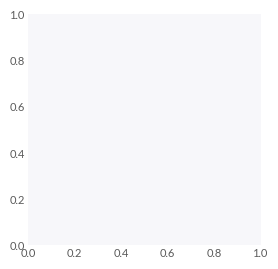

In [198]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(np.sort(diff_arr), np.arange(1, len(diff_arr)+1)/len(diff_arr))
ax.set_ylabel('ECDF')
ax.set_xlabel('difference in\nmaximum transcription rate')

In [41]:
df_wt_all[df_wt_all['promoter'] == 'mglBp']

,promoter,position,rate
214,mglBp,187,6390.994536


In [47]:
np.max(df_out_all[df_out_all['promoter'] == 'mglBp']['rates_w_mutation'].values[0])

np.float64(16142.859628929074)

In [134]:
from bson import decode_all

with open("../../data/metadata/transcriptionUnit.bson", "rb") as file:
    data = file.read()

# Decode all BSON documents into a list of dictionaries
documents = decode_all(data)
len(documents)
df = pd.DataFrame(documents)
df.head()

df[[('araB' in x) if x != None else False for x in df['name'] ]]

,_id,chromosome,datasetIds,genes,leftEndPosition,length,name,phantom,pseudo,rightEndPosition,strand,temporalId,termType
10158,ECOLITU000010166,NC_000913.3,[RHTECOLITUD02724],"[{'_id': 'RDBECOLIGNC00049', 'bnumber': 'b0063...",66493,3585,araA-araB,0,0,70077,-,"[TUS_TU0005,66493,70077,-]",long


,_id,chromosome,datasetIds,genes,leftEndPosition,length,name,phantom,pseudo,rightEndPosition,strand,temporalId,termType
10158,ECOLITU000010166,NC_000913.3,[RHTECOLITUD02724],"[{'_id': 'RDBECOLIGNC00049', 'bnumber': 'b0063...",66493,3585,araA-araB,0,0,70077,-,"[TUS_TU0005,66493,70077,-]",long


In [130]:
def plot_tx_rates_wildtype(df, promoter, save=False):
    
    
    fig, ax = plt.subplots(figsize=(6, 3))
    
    ax.scatter(
        df['mutation_pos'].values, 
        df['rates_w_mutation'].values, 
        s=6,
        color="#bec0c2",
    )
    
    
    ax.set_xlabel("position of TSS (relative to known)")
    ax.set_ylabel("transcription rate [A.U.]")
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 1.8, box.height])
    #ax.legend(loc='upper right', title='sequences')
    ax.grid(True)
    ax.set_title(f"{promoter}")
    if save:
        width_pts = 160
        height_pts = 80.12
        dpi = 100
        
        # Calculate figsize in inches
        width_in = get_pixels(width_pts) / dpi
        height_in = get_pixels(height_pts) / dpi
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.set_figwidth(width_in)
        fig.set_figheight(height_in)
        fig.set_dpi(dpi)
        ax.tick_params(axis='both', labelsize=3)
        ax.set_xlabel("position of TSS (relative to known)", fontsize=6)
        ax.set_ylabel("Transcription Rate [A.U.]", fontsize=6)  
        ax.set_title(f"{promoter} in {gc_descriptive}, replicate {rep}", fontsize=6)
        fig.savefig(f"emerging_promoters/{promoter}-{gc}-{rep}_lafleur.pdf")
        plt.close()
    return 
    

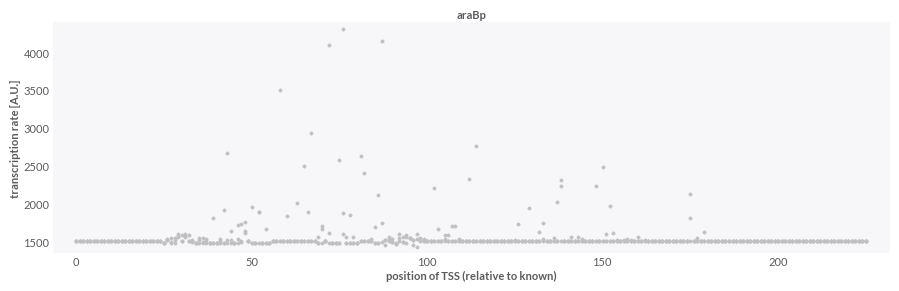

In [134]:
plot_tx_rates_wildtype(df_out_all, "araBp", save=False)

In [90]:
df_out_all

,promoter,tss,rates_w_mutation,rates_wo_mutation,positions
0,mglBp,2240566,22.880974,22.880974,-100
1,mglBp,2240566,77.330946,77.330946,-99
2,mglBp,2240566,389.071815,389.071815,-98
3,mglBp,2240566,351.637636,351.637636,-97
4,mglBp,2240566,398.791124,398.791124,-96
...,...,...,...,...,...
62,mglBp,2240566,195.173470,195.173470,-38
63,mglBp,2240566,238.793076,238.793076,-37
64,mglBp,2240566,186.234840,186.234840,-36
65,mglBp,2240566,224.503915,224.503915,-35


In [82]:
df_salis

172

In [92]:
df_wt_seq = pd.read_csv("files/emerging_promoter_tx_rates_w_gen_flanks.csv", usecols=[1, 2, 3, 4, 5, 6])
df_wt_seq.head(5)

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
0,araBp,29,2,-83,50.697486,48.475042
1,araBp,29,2,-82,92.107294,82.885838
2,araBp,29,2,-81,142.145742,133.125952
3,araBp,29,2,-80,269.133872,240.211082
4,araBp,29,2,-79,321.300749,292.639191


In [93]:
df_wt_seq[df_wt_seq['promoter'] == 'mglBp']

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
149,mglBp,9,2,-83,81.186961,79.329763
150,mglBp,9,2,-82,96.669920,101.992548
151,mglBp,9,2,-81,180.033653,202.880971
152,mglBp,9,2,-80,330.947718,352.598707
153,mglBp,9,2,-79,339.221512,359.331138
...,...,...,...,...,...,...
100719,mglBp,34,2,61,495.810676,412.045862
100720,mglBp,34,2,62,537.962904,445.441474
100721,mglBp,34,2,63,610.885742,548.693631
100722,mglBp,34,2,64,561.345328,515.298263


In [30]:
df_experiment = pd.read_csv("files/emerging_promoter_tx_rates.csv", usecols=[1, 2, 3, 4, 5, 6])
df_experiment.head()

,promoter,gc,rep,pos,rates_w_mutation,rates_wo_mutation
0,araBp,29,2,-83,63.938619,66.829667
1,araBp,29,2,-82,111.745962,105.412062
2,araBp,29,2,-81,171.366171,165.896161
3,araBp,29,2,-80,321.923234,289.217685
4,araBp,29,2,-79,384.228453,352.081894


In [31]:
df_rates_merge = df_experiment.merge(df_wt_seq, on=['promoter', 'gc', 'rep', 'pos'], suffixes=['_exp', '_wt'])
df_rates_merge.head()

,promoter,gc,rep,pos,rates_w_mutation_exp,rates_wo_mutation_exp,rates_w_mutation_wt,rates_wo_mutation_wt
0,araBp,29,2,-83,63.938619,66.829667,50.697486,48.475042
1,araBp,29,2,-82,111.745962,105.412062,92.107294,82.885838
2,araBp,29,2,-81,171.366171,165.896161,142.145742,133.125952
3,araBp,29,2,-80,321.923234,289.217685,269.133872,240.211082
4,araBp,29,2,-79,384.228453,352.081894,321.300749,292.639191


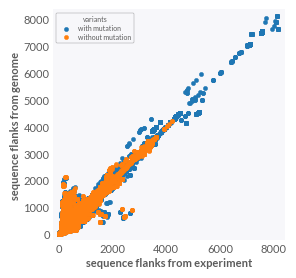

In [32]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(df_rates_merge.rates_w_mutation_exp.values, df_rates_merge.rates_w_mutation_wt.values, s=10, label='with mutation')
ax.scatter(df_rates_merge.rates_wo_mutation_exp.values, df_rates_merge.rates_wo_mutation_wt.values, s=10,label='without mutation')
ax.set_xlabel("sequence flanks from experiment")
ax.set_ylabel("sequence flanks from genome")
ax.legend(loc='upper left', title='variants')

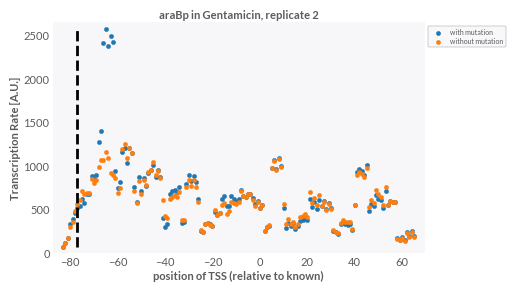

In [38]:
_, _, _, _ = plot_tx_rates(df_experiment, "araBp", 29, 2, save=False)

In [48]:
_, _,ax, fig = plot_tx_rates(df_experiment, "araBp", 2, 1, save=True)

In [184]:
df_proms = pd.read_csv("files/emerging_promoter_tx_rates_all_promoters.csv")
df_proms.head(5)

,promoter,tss,rates_w_mutation,rates_wo_mutation,positions
0,yggNp1,3101798,39.093416,38.687936,-83
1,yggNp1,3101798,70.066070,69.335252,-82
2,yggNp1,3101798,87.079807,86.149421,-81
3,yggNp1,3101798,120.884770,120.265323,-80
4,yggNp1,3101798,282.737834,285.174412,-79


In [185]:
df_proms[df_proms['promoter'] == 'mglBp']

,promoter,tss,rates_w_mutation,rates_wo_mutation,positions
31886,mglBp,2240566,81.321115,81.029454,-83
31887,mglBp,2240566,84.290652,82.797869,-82
31888,mglBp,2240566,81.984195,79.492968,-81
31889,mglBp,2240566,164.891244,163.002017,-80
31890,mglBp,2240566,308.521644,306.107661,-79
...,...,...,...,...,...
32030,mglBp,2240566,808.528228,813.851130,61
32031,mglBp,2240566,738.543064,744.677800,62
32032,mglBp,2240566,520.394458,513.721691,63
32033,mglBp,2240566,518.164518,511.192839,64


In [186]:
def plot_tx_rates_wildtype(df, promoter, save=False):
    
    
    fig, ax = plt.subplots(figsize=(6, 3))
    
    ax.scatter(
        df['positions'].values, 
        df['rates_wo_mutation'].values, 
        label='without mutation', 
        s=6,
        color="#bec0c2",
    )
    ax.scatter(
        df['positions'].values, 
        df['rates_w_mutation'].values, 
        label='with mutation', 
        s=6,
        color="#ab85ac"
    )
    
    
    ax.set_xlabel("position of TSS (relative to known)")
    ax.set_ylabel("transcription rate [A.U.]")
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 1.8, box.height])
    #ax.legend(loc='upper right', title='sequences')
    ax.grid(True)
    ax.set_title(f"{promoter}")
    if save:
        width_pts = 160
        height_pts = 80.12
        dpi = 100
        
        # Calculate figsize in inches
        width_in = get_pixels(width_pts) / dpi
        height_in = get_pixels(height_pts) / dpi
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.set_figwidth(width_in)
        fig.set_figheight(height_in)
        fig.set_dpi(dpi)
        ax.tick_params(axis='both', labelsize=3)
        ax.set_xlabel("position of TSS (relative to known)", fontsize=6)
        ax.set_ylabel("Transcription Rate [A.U.]", fontsize=6)  
        ax.set_title(f"{promoter} in {gc_descriptive}, replicate {rep}", fontsize=6)
        #fig.savefig(f"emerging_promoters/{promoter}-{gc}-{rep}_lafleur.pdf")
        plt.close()
    return 
    

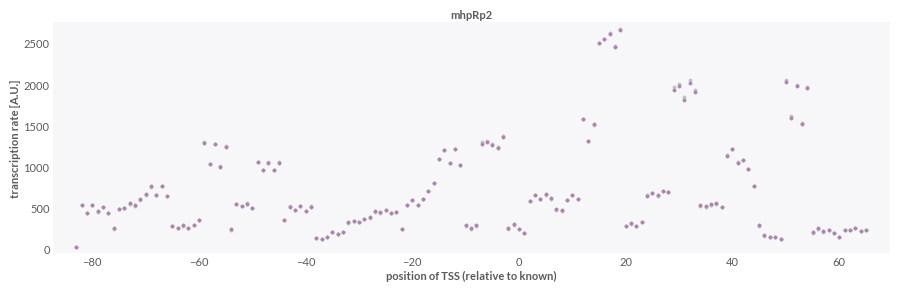

In [187]:
prom = "mhpRp2"
plot_tx_rates_wildtype(df_proms[df_proms['promoter'] == prom], prom)